In [1]:
# Google Colab環境のセットアップ
# 必要なライブラリをインストール
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 142.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
# Roboflowからデータセットをダウンロード
from roboflow import Roboflow
import json
import os
from pathlib import Path
from google.colab import files

# Google Colab環境で設定ファイルをアップロード
print("設定ファイルをアップロードしてください（config/api.config）")
uploaded = files.upload()
config_path = list(uploaded.keys())[0]

# 設定ファイルを読み込み
with open(config_path, 'r') as f:
    config = json.load(f)

roboflow_config = config['roboflow']

# Roboflowからデータセットをダウンロード
rf = Roboflow(api_key=roboflow_config['api_key'])
project = rf.workspace(roboflow_config['workspace']).project(roboflow_config['project'])
version = project.version(roboflow_config['version'])
dataset = version.download("yolov11")

print(f"データセットのダウンロード完了: {dataset.location}")

設定ファイルをアップロードしてください（config/api.config）


Saving api.config to api.config
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PingPongBall-4 in yolov11:: 100%|██████████| 697/697 [00:00<00:00, 2690.60it/s]

データセットのダウンロード完了: /content/PingPongBall-4


In [3]:
# データセットの構造を確認
import os
import yaml

# data.yamlファイルを読み込んで内容を確認
data_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("データセット設定:")
print(yaml.dump(data_config, default_flow_style=False, allow_unicode=True))

# 訓練データとバリデーションデータの画像数を確認
train_images = os.path.join(dataset.location, "train", "images")
valid_images = os.path.join(dataset.location, "valid", "images")

train_count = len([f for f in os.listdir(train_images) if f.endswith(('.jpg', '.png', '.jpeg'))])
valid_count = len([f for f in os.listdir(valid_images) if f.endswith(('.jpg', '.png', '.jpeg'))])

print(f"\n訓練データ画像数: {train_count}")
print(f"検証データ画像数: {valid_count}")

データセット設定:
names:
- Paddle
- Ping Pong Ball
- Ping Pong Table
nc: 3
roboflow:
  license: Public Domain
  project: pingpongball-nexmm
  url: https://universe.roboflow.com/tt-test/pingpongball-nexmm/dataset/4
  version: 4
  workspace: tt-test
test: ../test/images
train: ../train/images
val: ../valid/images


訓練データ画像数: 312
検証データ画像数: 32


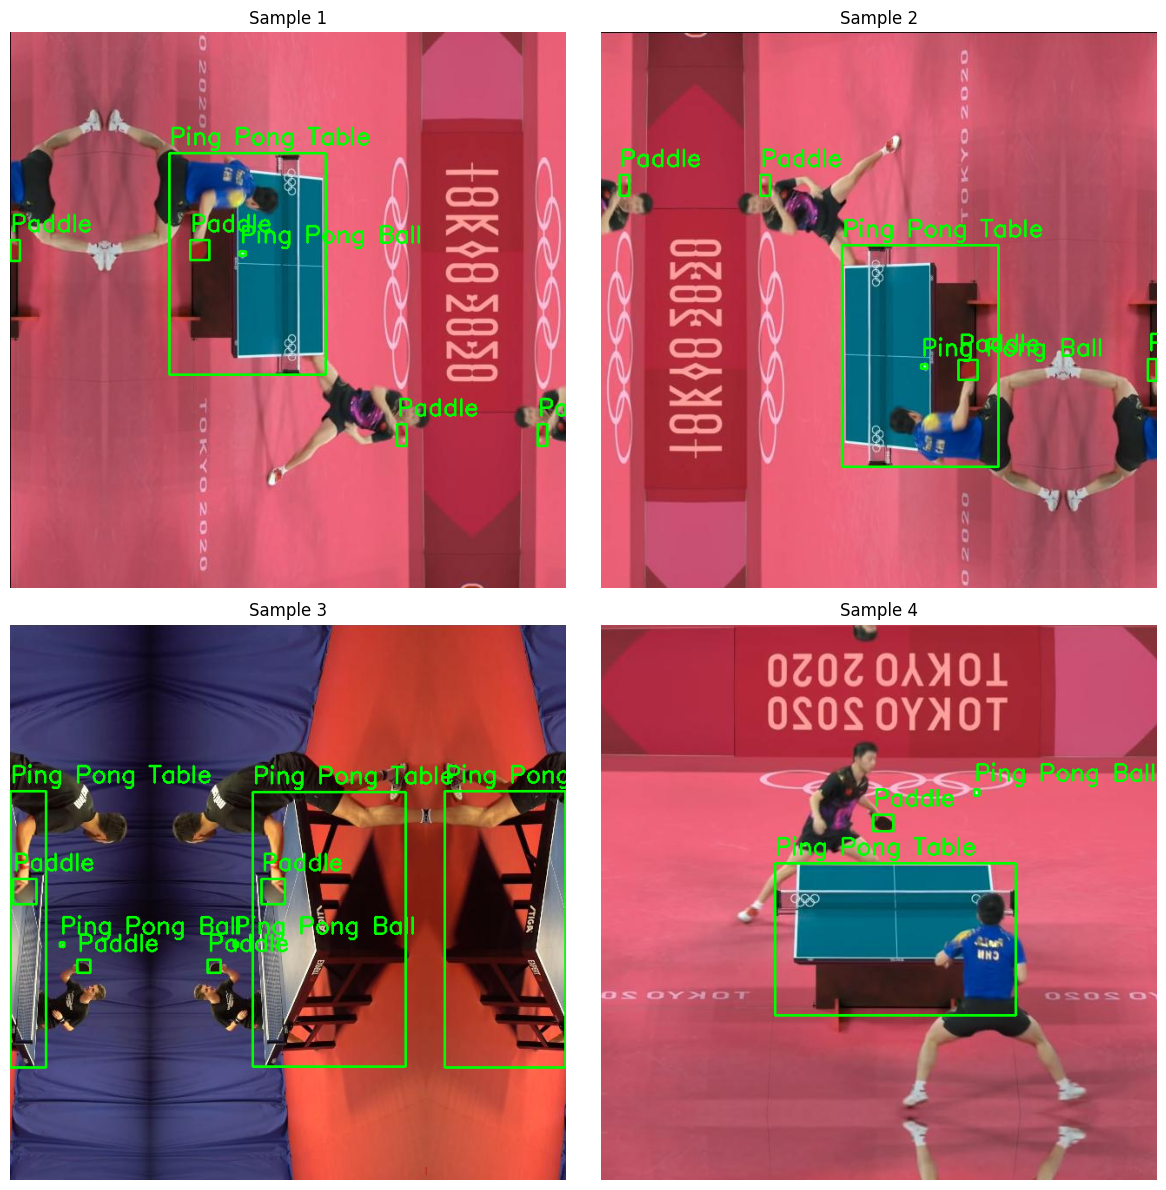

In [4]:
# サンプル画像を可視化
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

def visualize_sample_with_labels(image_path, label_path, class_names):
    """画像とアノテーションを可視化"""
    # 画像を読み込み
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # ラベルを読み込み
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            labels = f.readlines()

        # バウンディングボックスを描画
        for label in labels:
            parts = label.strip().split()
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:5])

            # YOLO形式から座標に変換
            x1 = int((x_center - width/2) * w)
            y1 = int((y_center - height/2) * h)
            x2 = int((x_center + width/2) * w)
            y2 = int((y_center + height/2) * h)

            # 矩形を描画
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, class_names[class_id], (x1, y1-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    return img

# 訓練データからサンプルを表示
train_img_dir = Path(dataset.location) / "train" / "images"
train_label_dir = Path(dataset.location) / "train" / "labels"

sample_images = list(train_img_dir.glob("*.jpg"))[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

for idx, img_path in enumerate(sample_images):
    label_path = train_label_dir / (img_path.stem + ".txt")
    img = visualize_sample_with_labels(img_path, label_path, data_config['names'])
    axes[idx].imshow(img)
    axes[idx].set_title(f"Sample {idx+1}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# YOLOv11モデルの訓練
from ultralytics import YOLO

# YOLOv11モデルを初期化（事前学習済みモデルから開始）
# モデルサイズの選択: n(nano), s(small), m(medium), l(large), x(xlarge)
# 卓球台検出なので、まずはyolo11n.ptから始める
model = YOLO('yolo11n.pt')  # 軽量モデル

# 訓練パラメータの設定
results = model.train(
    data=data_yaml_path,        # データセット設定ファイル
    epochs=100,                  # エポック数
    imgsz=640,                   # 入力画像サイズ
    batch=16,                    # バッチサイズ（GPU メモリに応じて調整）
    name='table_detector_v1',    # プロジェクト名
    patience=20,                 # Early stoppingのpatience
    save=True,                   # モデルの保存
    save_period=10,              # 10エポックごとにチェックポイント保存
    cache=True,                  # データセットをキャッシュして高速化
    device=0,                    # GPU使用（CPU の場合は 'cpu'）
    workers=2,                   # データローダーのワーカー数
    project='table_detection',   # プロジェクトフォルダ
    exist_ok=True,               # 既存のプロジェクトを上書き
    pretrained=True,             # 事前学習済み重みを使用
    optimizer='auto',            # オプティマイザー自動選択
    verbose=True,                # 詳細なログ出力
    seed=42,                     # 再現性のためのシード値
    deterministic=True,          # 決定的な訓練
    single_cls=False,            # マルチクラス検出
    rect=False,                  # 矩形訓練
    cos_lr=True,                 # コサインLRスケジューラ
    close_mosaic=10,             # 最後の10エポックでモザイク拡張を無効化
    amp=True,                    # 自動混合精度訓練
    fraction=1.0,                # 使用するデータセットの割合
    profile=False,               # プロファイリング
    freeze=None,                 # 凍結するレイヤー数
    lr0=0.01,                    # 初期学習率
    lrf=0.01,                    # 最終学習率係数
    momentum=0.937,              # モメンタム
    weight_decay=0.0005,         # 重み減衰
    warmup_epochs=3.0,           # ウォームアップエポック数
    warmup_momentum=0.8,         # ウォームアップモメンタム
    warmup_bias_lr=0.1,          # ウォームアップバイアス学習率
    box=7.5,                     # ボックスロスの重み
    cls=0.5,                     # クラスロスの重み
    dfl=1.5,                     # DFLロスの重み
    pose=12.0,                   # ポーズロスの重み（検出タスクでは無視される）
    kobj=1.0,                    # キーポイント objロスの重み
    label_smoothing=0.0,         # ラベルスムージング
    nbs=64,                      # 正規化バッチサイズ
    hsv_h=0.015,                 # HSV色相拡張
    hsv_s=0.7,                   # HSV彩度拡張
    hsv_v=0.4,                   # HSV明度拡張
    degrees=0.0,                 # 回転拡張（度）
    translate=0.1,               # 平行移動拡張
    scale=0.5,                   # スケール拡張
    shear=0.0,                   # せん断拡張
    perspective=0.0,             # 透視変換拡張
    flipud=0.0,                  # 上下反転確率
    fliplr=0.5,                  # 左右反転確率
    mosaic=1.0,                  # モザイク拡張確率
    mixup=0.0,                   # ミックスアップ拡張確率
    copy_paste=0.0,              # コピー&ペースト拡張確率
)

print("\n訓練が完了しました！")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/PingPongBall-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None,

In [6]:
# 検証セットでモデルを評価
metrics = model.val()

print("\n=== 評価結果 ===")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 877.4±257.0 MB/s, size: 46.7 KB)
val: Scanning /content/PingPongBall-4/valid/labels.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 14.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8it/s 1.1s
                   all         32        211       0.71      0.608      0.607      0.388
                Paddle         28         82      0.672      0.402      0.443      0.223
        Ping Pong Ball         32         62      0.615      0.452      0.426      0.104
       Ping Pong Table         30         67      0.844       0.97      0.952      0.837
Speed: 5.9ms preprocess, 7.4ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/runs/detect/val

=== 評価結果 ==

訓練結果:


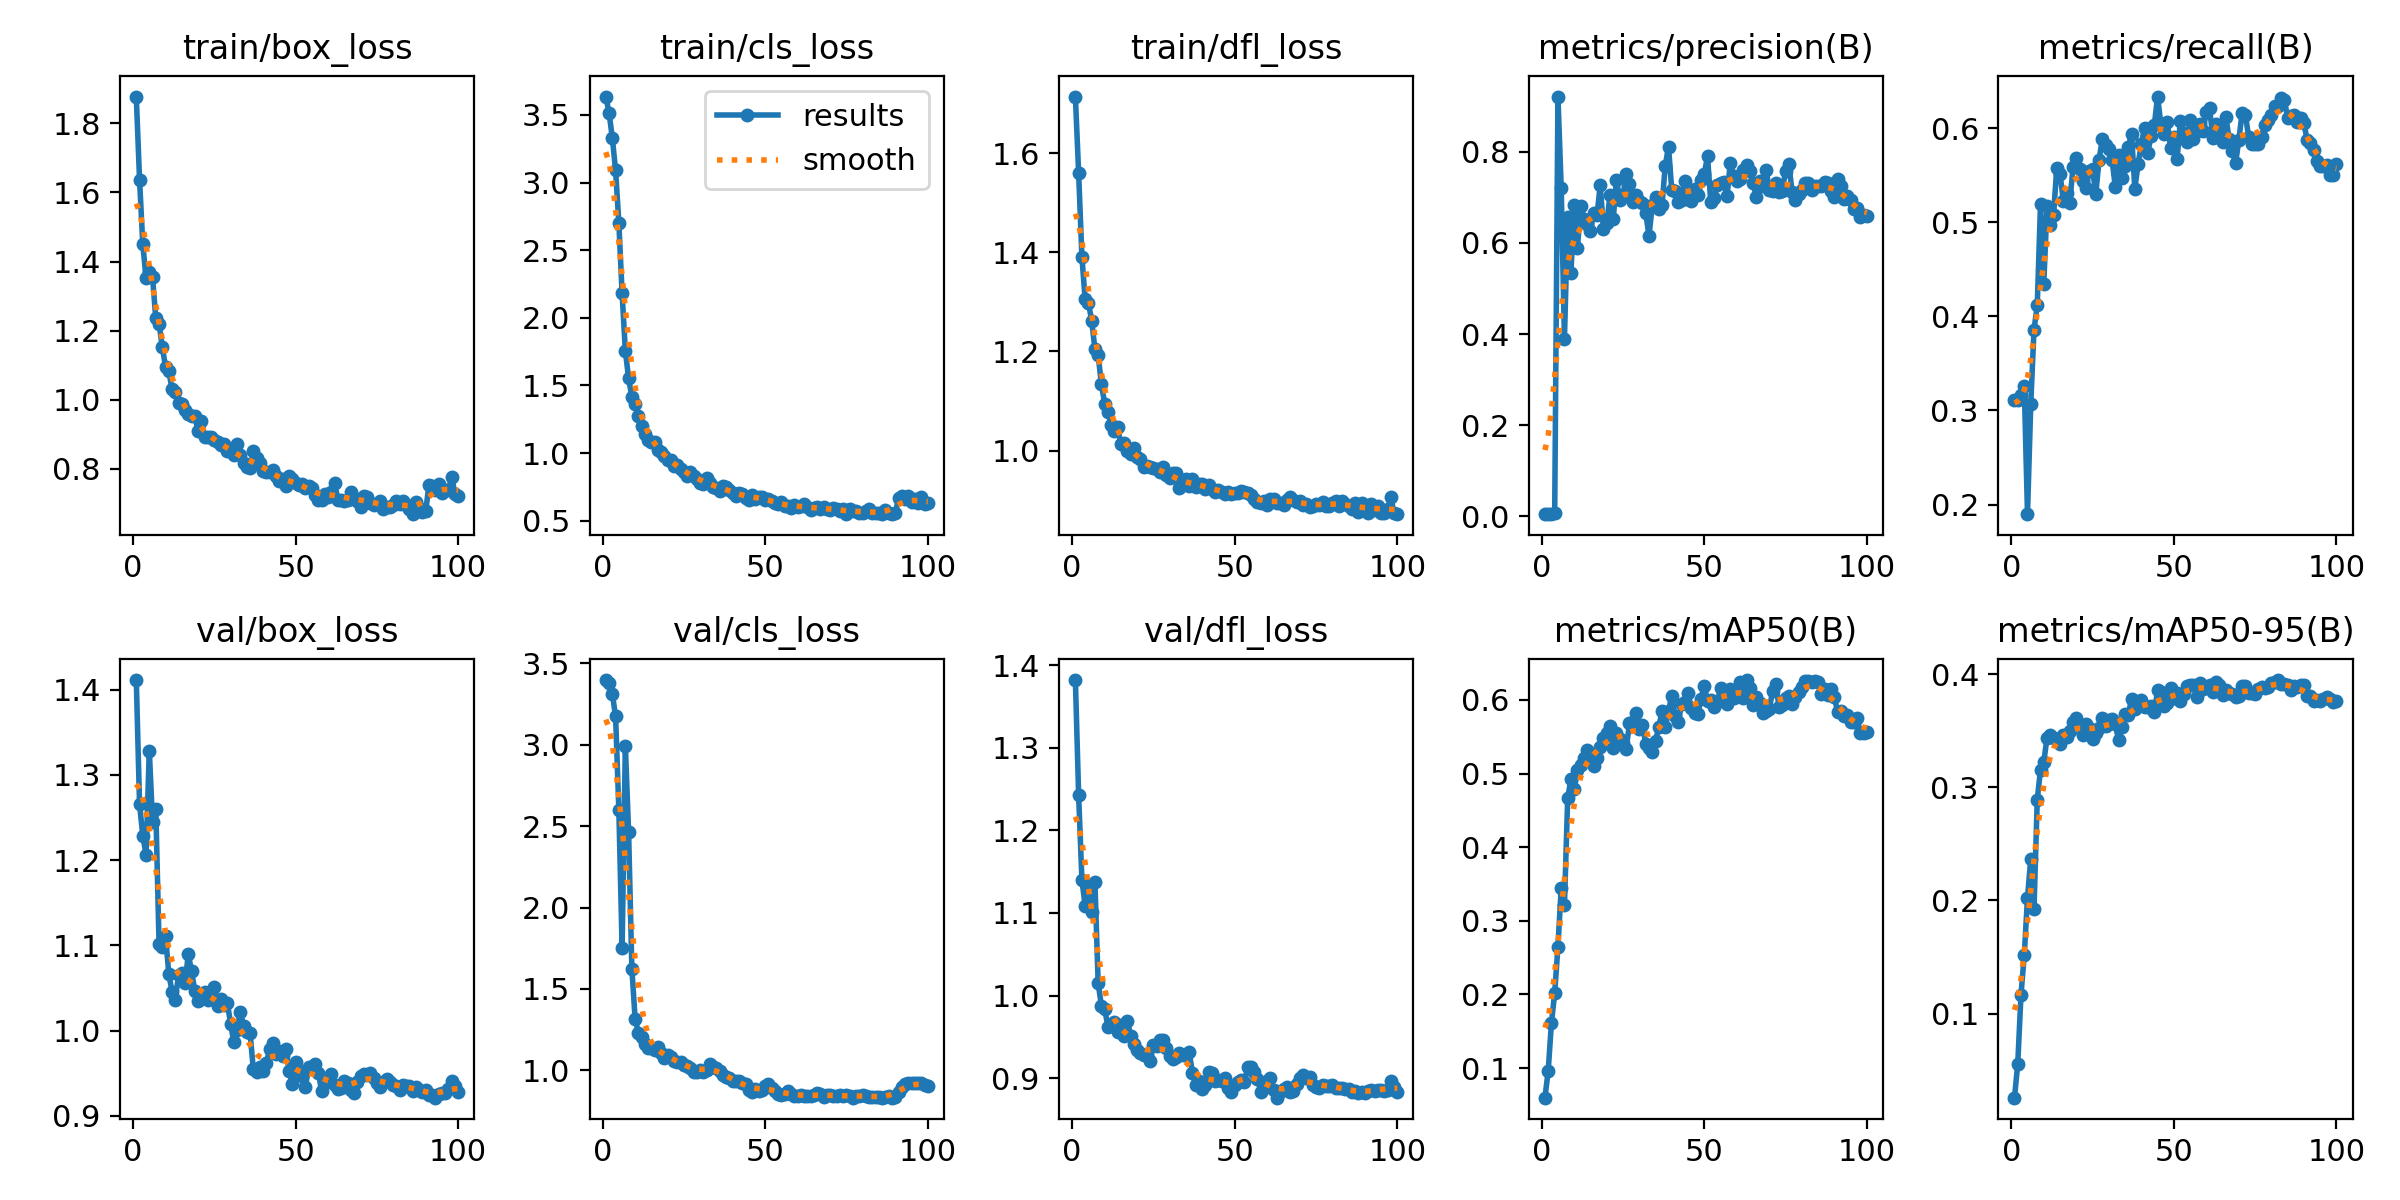


混同行列:


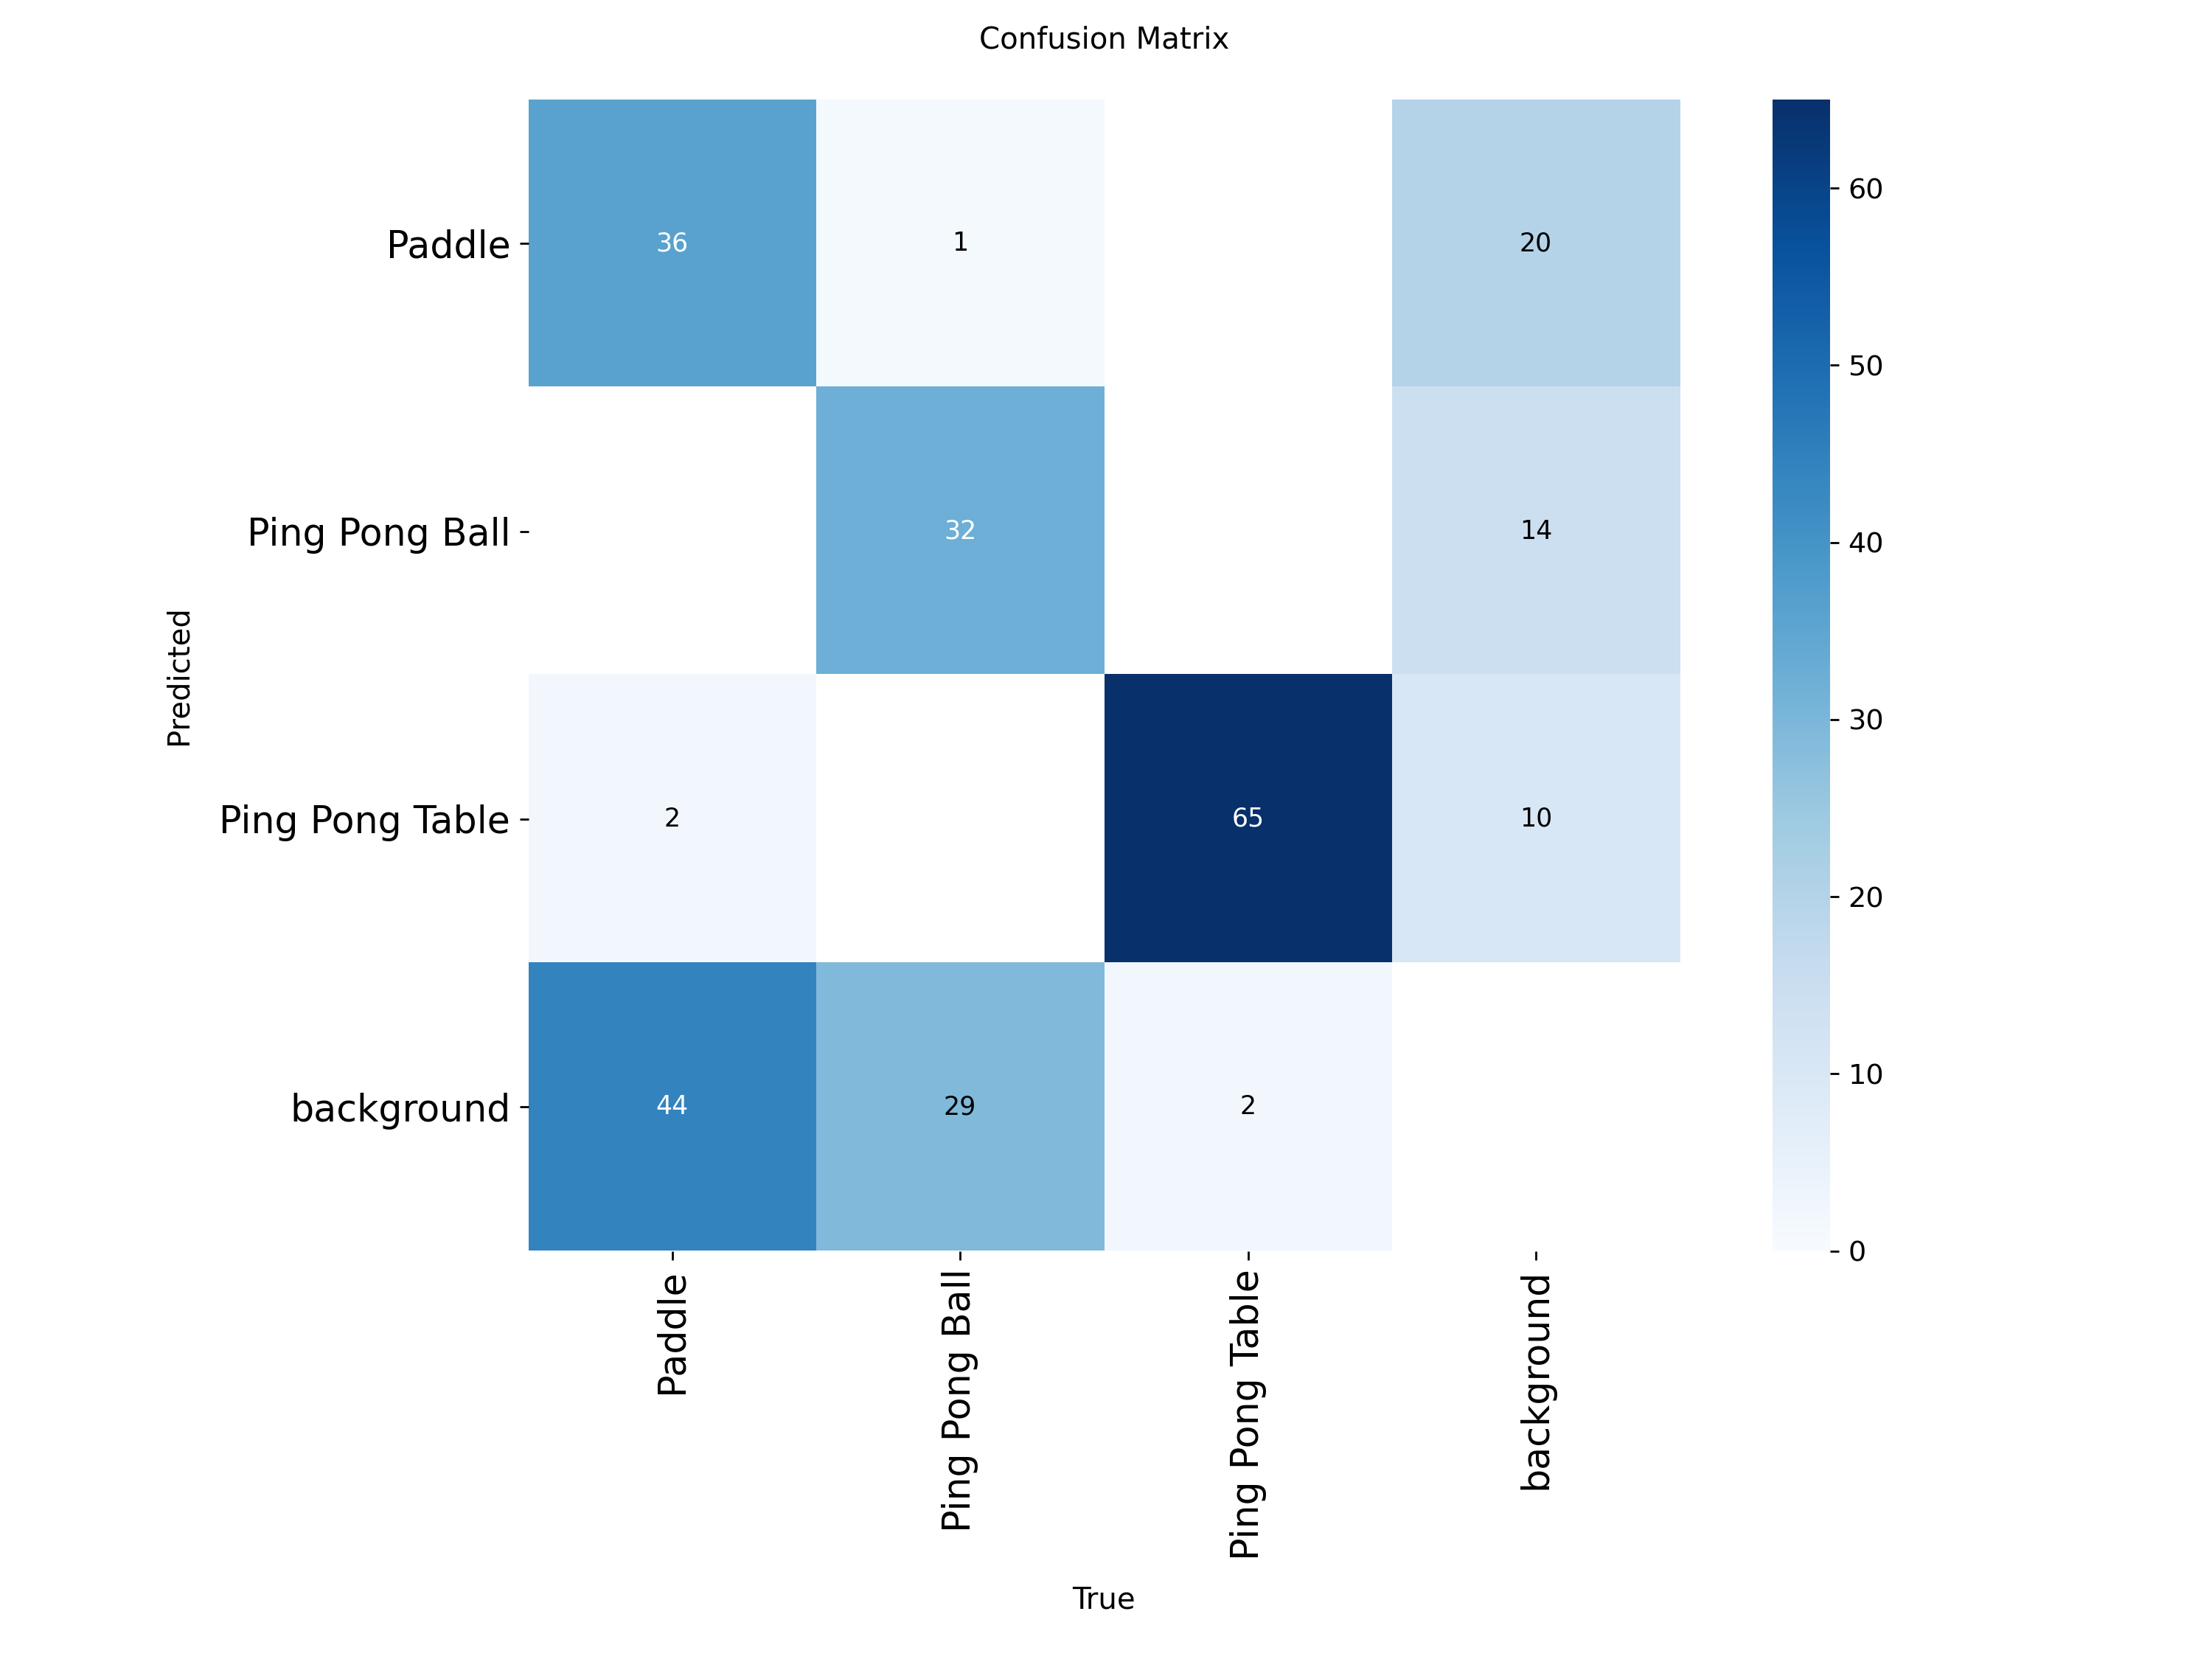


バリデーション予測結果:


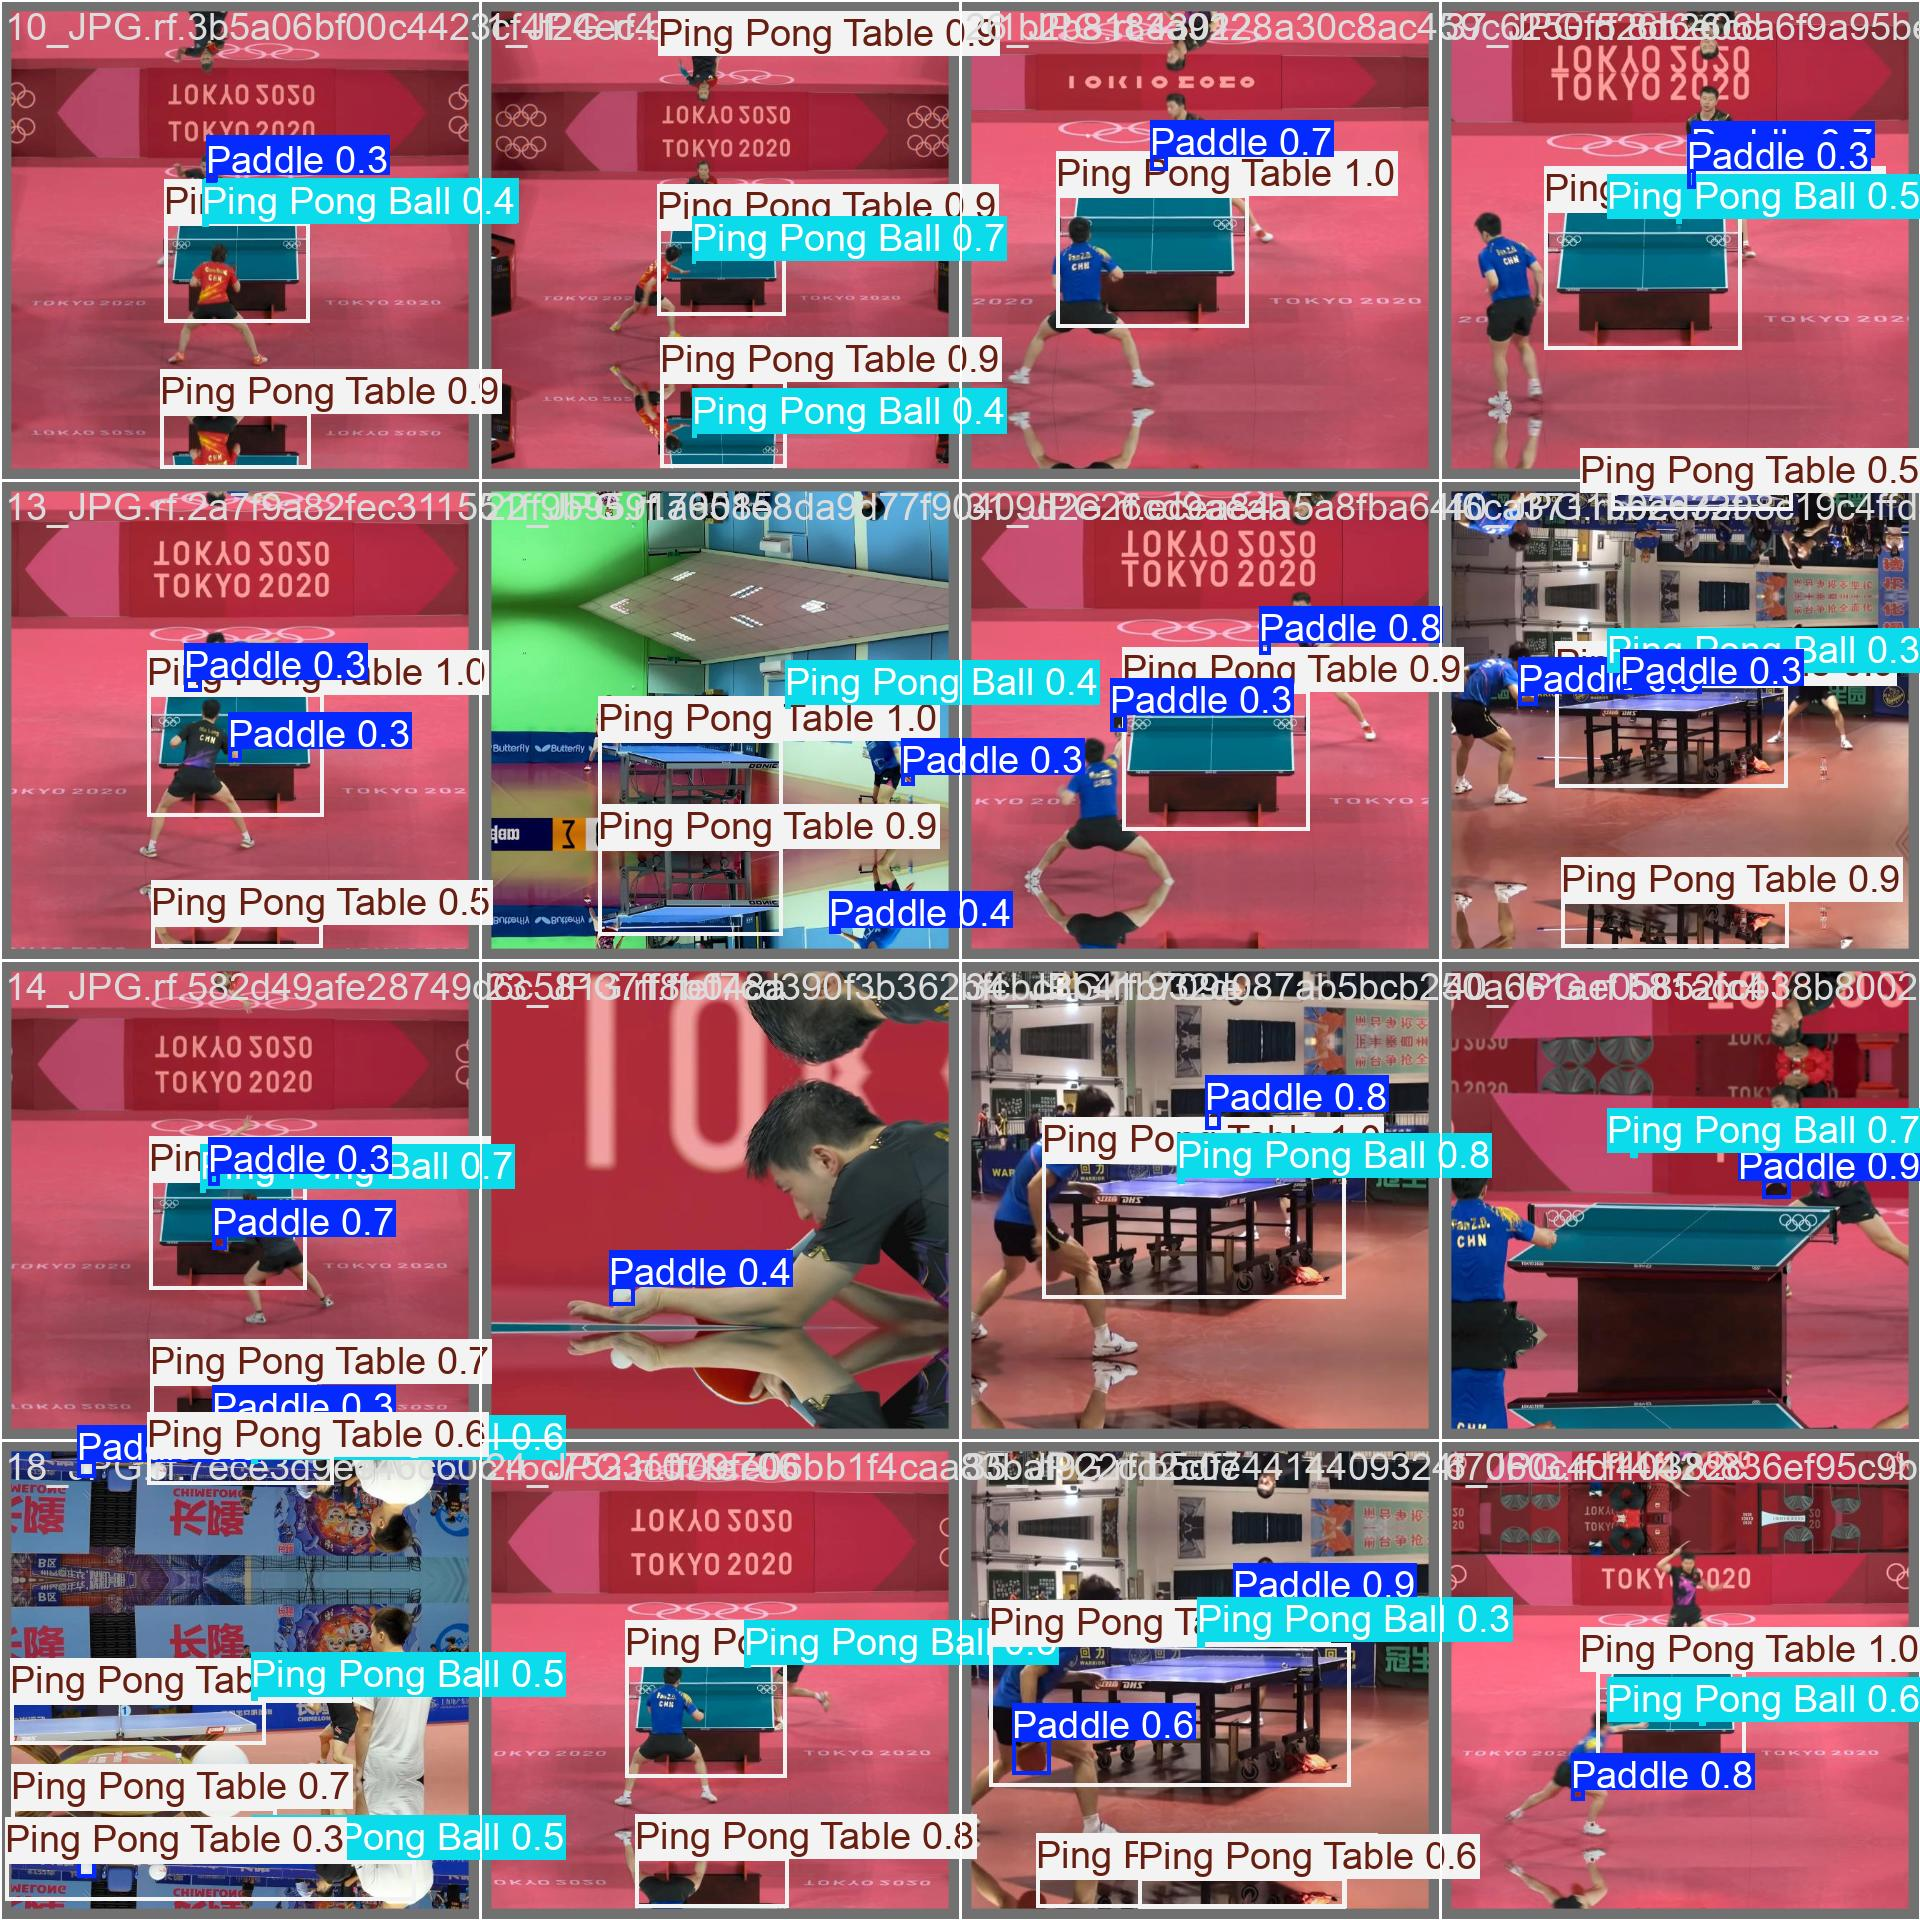

In [9]:
# 訓練結果の可視化
from IPython.display import Image, display
import glob

# 訓練結果のディレクトリを探す
results_dir = "/content/runs/detect/table_detection/table_detector_v1"

# 訓練曲線を表示
results_plot = os.path.join(results_dir, "results.png")
if os.path.exists(results_plot):
    print("訓練結果:")
    display(Image(filename=results_plot))

# 混同行列を表示
confusion_matrix = os.path.join(results_dir, "confusion_matrix.png")
if os.path.exists(confusion_matrix):
    print("\n混同行列:")
    display(Image(filename=confusion_matrix))

# バリデーションバッチの予測結果を表示
val_batches = sorted(glob.glob(os.path.join(results_dir, "val_batch*_pred.jpg")))
if val_batches:
    print("\nバリデーション予測結果:")
    for batch_img in val_batches[:2]:  # 最初の2つのバッチを表示
        display(Image(filename=batch_img))


In [10]:
# ベストモデルをロード
best_model_path = os.path.join(results_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

print(f"ベストモデル: {best_model_path}")

# ONNXフォーマットにエクスポート（推論の高速化とデプロイ用）
onnx_path = best_model.export(format='onnx')
print(f"\nONNXモデルをエクスポートしました: {onnx_path}")

# TorchScriptフォーマットにもエクスポート
torchscript_path = best_model.export(format='torchscript')
print(f"TorchScriptモデルをエクスポートしました: {torchscript_path}")

ベストモデル: /content/runs/detect/table_detection/table_detector_v1/weights/best.pt
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/detect/table_detection/table_detector_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 198ms
Prepared 6 packages in 5.74s
Installed 6 packages in 252ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.1
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 6

Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 8.3s, saved as '/content/runs/detect/table_detection/table_detector_v1/weights/best.onnx' (10.1 MB)

Export complete (8.8s)
Results saved to /content/runs/detect/table_detection/table_detector_v1/weights
Predict:         yolo predict task=detect model=/content/runs/detect/table_detection/table_detector_v1/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/table_detection/table_detector_v1/weights/best.onnx imgsz=640 data=/content/PingPongBall-4/data.yaml  
Visualize:       https://netron.app

ONNXモデルをエクスポートしました: /content/runs/detect/table_detection/table_detector_v1/weights/best.onnx
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/detect/table_detection/table_detector_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW a

In [15]:
# Google Driveにモデルを保存（Colab使用時）
# Google Driveをマウント
from google.colab import drive
drive.mount('/content/drive')

# モデルをGoogle Driveにコピー
import shutil

drive_model_dir = '/content/drive/MyDrive/Visuable_for_you_tabletennis/table_detection_models'
os.makedirs(drive_model_dir, exist_ok=True)

# ベストモデルをコピー
shutil.copy(best_model_path, os.path.join(drive_model_dir, 'best.pt'))
shutil.copy(onnx_path, os.path.join(drive_model_dir, 'best.onnx'))
shutil.copy(torchscript_path, os.path.join(drive_model_dir, 'best.torchscript'))

print(f"モデルをGoogle Driveに保存しました: {drive_model_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
モデルをGoogle Driveに保存しました: /content/drive/MyDrive/Visuable_for_you_Table_Tennis/table_detection_models


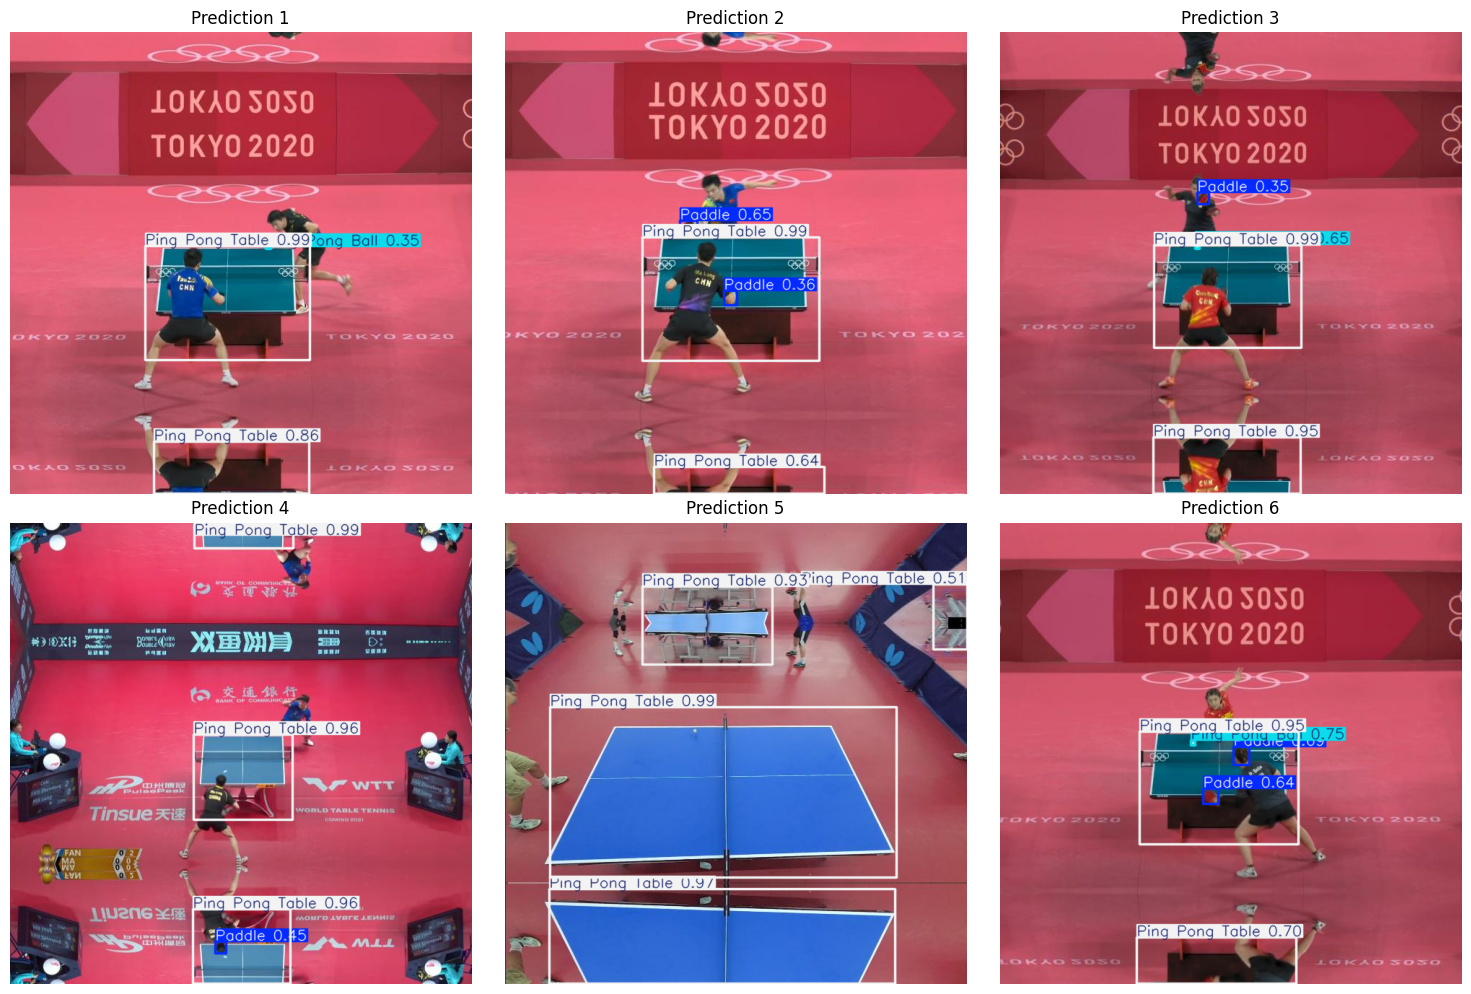


最初のテスト画像の検出結果:
クラス: Ping Pong Table, 信頼度: 0.99, BBox: [187.38128662109375, 296.85699462890625, 415.70330810546875, 454.950439453125]
クラス: Ping Pong Table, 信頼度: 0.86, BBox: [199.43092346191406, 567.4956665039062, 414.7967529296875, 639.9186401367188]
クラス: Ping Pong Ball, 信頼度: 0.35, BBox: [354.98480224609375, 297.01873779296875, 361.69195556640625, 300.95147705078125]


In [12]:
# バリデーションデータでテスト推論
valid_img_dir = Path(dataset.location) / "valid" / "images"
test_images = list(valid_img_dir.glob("*.jpg"))[:6]

# 推論を実行
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, img_path in enumerate(test_images):
    # 推論
    results = best_model.predict(
        source=str(img_path),
        conf=0.25,  # 信頼度閾値
        iou=0.45,   # NMS IOU閾値
        verbose=False
    )

    # 結果を描画
    result_img = results[0].plot()
    result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(result_img)
    axes[idx].set_title(f"Prediction {idx+1}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# 検出された物体の情報を表示
print("\n最初のテスト画像の検出結果:")
first_result = best_model.predict(source=str(test_images[0]), verbose=False)[0]
for box in first_result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    bbox = box.xyxy[0].tolist()
    print(f"クラス: {data_config['names'][class_id]}, 信頼度: {confidence:.2f}, BBox: {bbox}")

In [13]:
# モデルのサマリー情報を表示
print("=== モデル情報 ===")
print(f"モデルアーキテクチャ: YOLOv11n")
print(f"入力サイズ: 640x640")
print(f"クラス数: {len(data_config['names'])}")
print(f"クラス名: {data_config['names']}")
print(f"\n訓練データ数: {train_count}")
print(f"検証データ数: {valid_count}")
print(f"\n最終評価指標:")
print(f"  - mAP50: {metrics.box.map50:.4f}")
print(f"  - mAP50-95: {metrics.box.map:.4f}")
print(f"  - Precision: {metrics.box.mp:.4f}")
print(f"  - Recall: {metrics.box.mr:.4f}")
print(f"\nモデル保存先:")
print(f"  - PyTorch: {best_model_path}")
print(f"  - ONNX: {onnx_path}")
print(f"  - TorchScript: {torchscript_path}")
print(f"  - Google Drive: {drive_model_dir}")

=== モデル情報 ===
モデルアーキテクチャ: YOLOv11n
入力サイズ: 640x640
クラス数: 3
クラス名: ['Paddle', 'Ping Pong Ball', 'Ping Pong Table']

訓練データ数: 312
検証データ数: 32

最終評価指標:
  - mAP50: 0.6071
  - mAP50-95: 0.3877
  - Precision: 0.7103
  - Recall: 0.6081

モデル保存先:
  - PyTorch: /content/runs/detect/table_detection/table_detector_v1/weights/best.pt
  - ONNX: /content/runs/detect/table_detection/table_detector_v1/weights/best.onnx
  - TorchScript: /content/runs/detect/table_detection/table_detector_v1/weights/best.torchscript
  - Google Drive: /content/drive/MyDrive/table_detection_models
